#IMPORTING ALL THE IMPORTANT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

#LOAD THE DATASET

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#DATA CLEANING

In [7]:
df.drop(columns="Cabin", inplace=True)

In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [10]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#PERFORMING EXPLORATORY DATA ANALYSIS

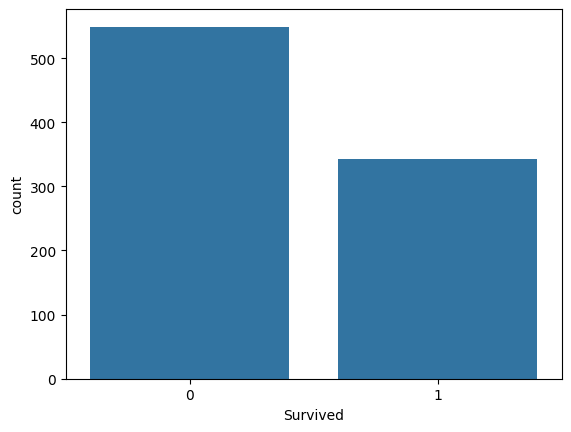

In [12]:
sns.countplot(x="Survived", data=df)
plt.show()

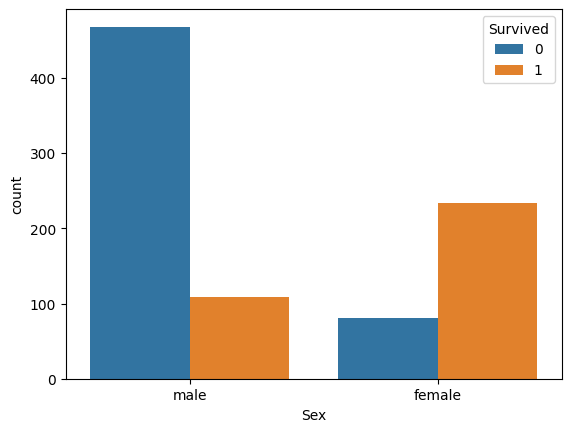

In [13]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

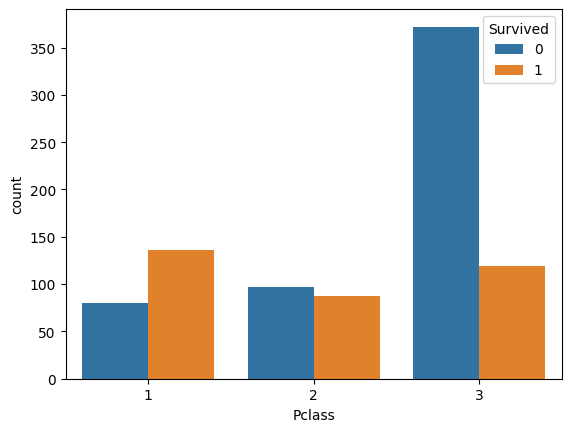

In [14]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

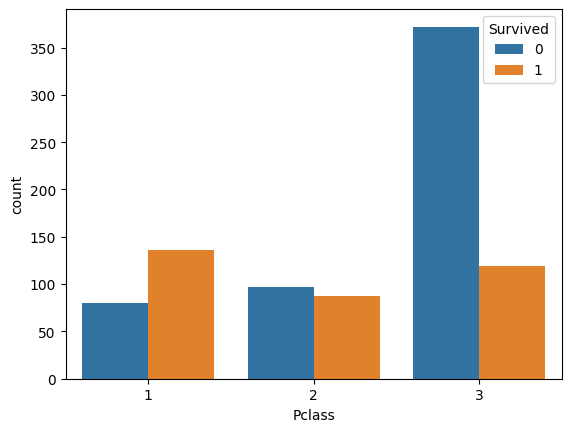

In [15]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

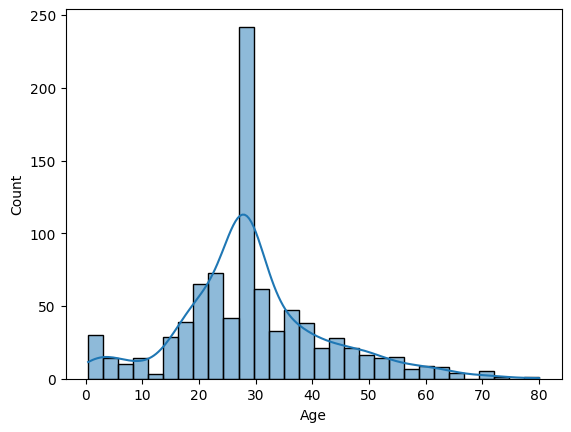

In [16]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.show()

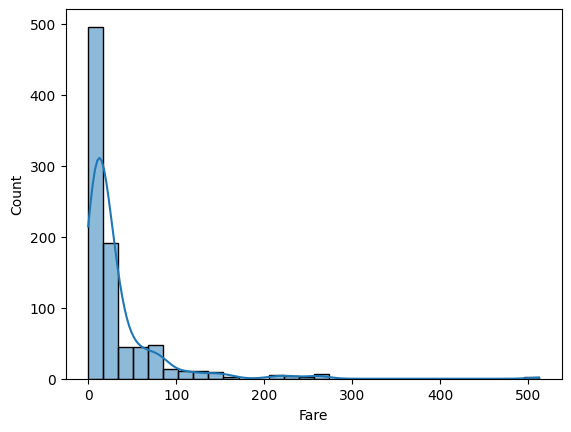

In [17]:
sns.histplot(df["Fare"], bins=30, kde=True)
plt.show()

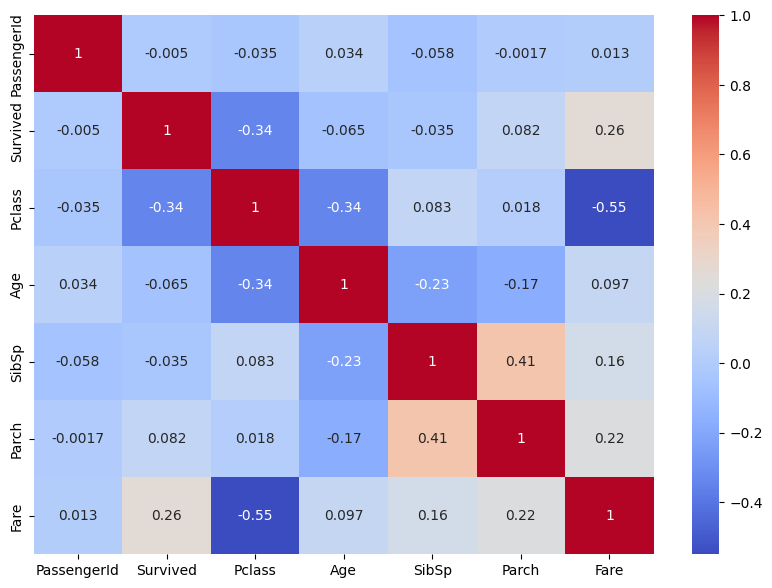

In [18]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

#FEATURE SELECTION

In [19]:
df.drop(columns=["PassengerId","Name","Ticket"], inplace=True)

In [20]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#LABEL ENCODING

In [21]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [34]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


#TRAIN TEST SPLIT

In [23]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

#FITTING THE MODELS

1.LOGISTIC REGRESSION

In [24]:
lr = LogisticRegression()

lr.fit(X_train, y_train)


LogisticRegression()

In [25]:
lr_pred = lr.predict(X_test)

2.DECISION TREE

In [26]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
dt_pred = dt.predict(X_test)

3.RANDOM FOREST

In [28]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
rf_pred = rf.predict(X_test)

#EVALUATING THE MODEL

In [30]:
def evaluate_model(name, y_test, pred, prob):

    print(name)
    print("Accuracy :", accuracy_score(y_test,pred))
    print("Precision:", precision_score(y_test,pred))
    print("Recall   :", recall_score(y_test,pred))
    print("ROC-AUC  :", roc_auc_score(y_test,prob))
    print("\nClassification Report")
    print(classification_report(y_test,pred))
    print("-"*60)

1.LOGISTIC REGRESSION

In [31]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr.predict_proba(X_test)[:,1]
)

Logistic Regression
Accuracy : 0.8100558659217877
Precision: 0.7857142857142857
Recall   : 0.7432432432432432
ROC-AUC  : 0.8823680823680824

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

------------------------------------------------------------


2.DECISION TREE

In [32]:
evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt.predict_proba(X_test)[:,1]
)

Decision Tree
Accuracy : 0.7821229050279329
Precision: 0.7215189873417721
Recall   : 0.7702702702702703
ROC-AUC  : 0.8001930501930501

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179

------------------------------------------------------------


3.RANDOM FOREST

In [33]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf.predict_proba(X_test)[:,1]
)

Random Forest
Accuracy : 0.8212290502793296
Precision: 0.8088235294117647
Recall   : 0.7432432432432432
ROC-AUC  : 0.8988416988416987

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

------------------------------------------------------------


#CONFUSION MATRIX

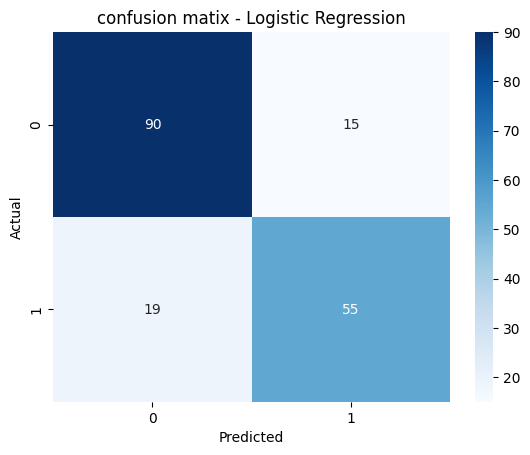

In [44]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("confusion matix - Logistic Regression")

plt.show()

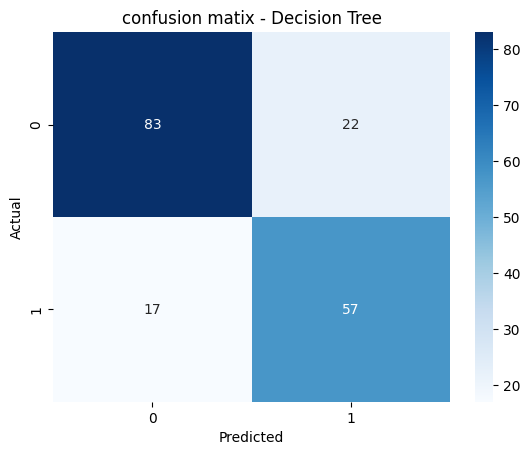

In [45]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("confusion matix - Decision Tree")

plt.show()

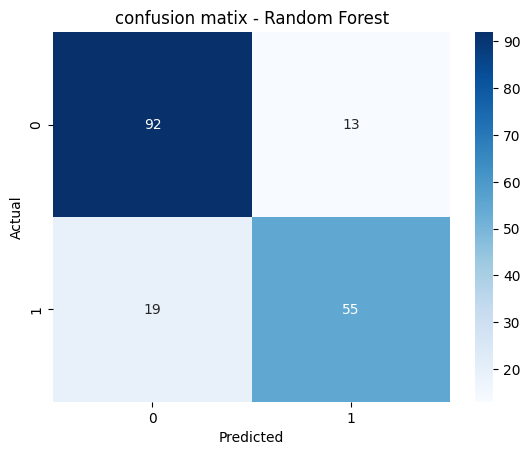

In [46]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("confusion matix - Random Forest")

plt.show()

#ROC CURVE

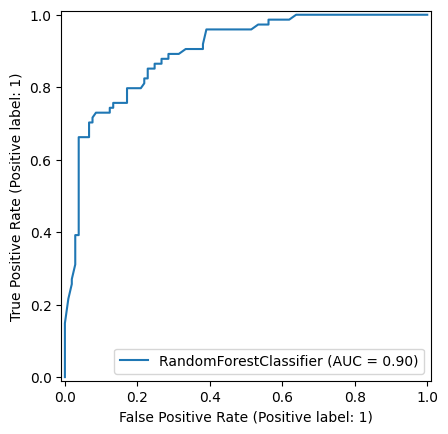

In [36]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.show()

#IMPORTANT FEATURES

In [37]:
importance = pd.DataFrame({"Feature":X.columns, "Importance":rf.feature_importances_})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
1,Sex,0.271410
5,Fare,0.265010
2,Age,0.249995
0,Pclass,0.086957
3,SibSp,0.053685
4,Parch,0.039897
6,Embarked,0.033044


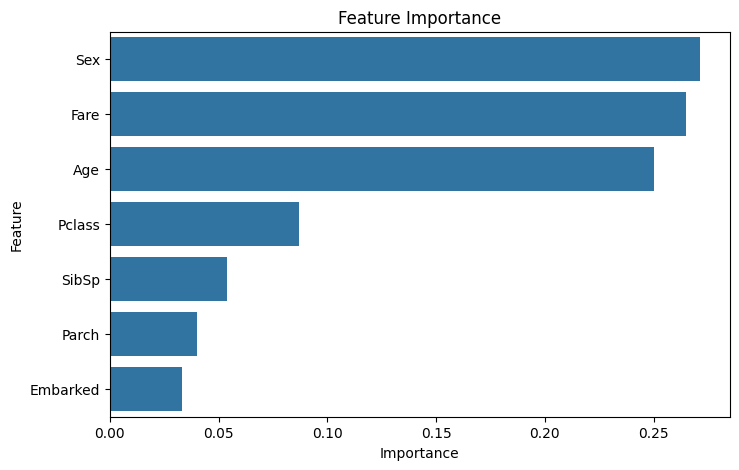

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")

plt.show()

In [40]:
import joblib

joblib.dump(lr,"logistic_regression.pkl")

joblib.dump(dt,"decision_tree.pkl")

joblib.dump(rf,"random_forest.pkl")

['random_forest.pkl']